## Quantitative Analysis

- **Objective:** <br>

  - Using the monthly stock of unique active consents as a proxy for Open Finance adoption and PIX transactions as a proxy for the payment ecosystem, the analysis examines the relationship between Open Finance expansion and payment system activity.

  - The objective is to assess whether Open Finance expansion contributes to broader financial digitalization and payment system dynamics, while isolating its effects from general macroeconomic fluctuations. <br>
  
- **Variables and Data Sources:** <br>

  - Dependent Variable: <br>

    - [pix](https://dadosabertos.bcb.gov.br/dataset/pix/resource/d5430811-0ef7-4404-bc87-d76aa5cfebcd): Quantity and financial volume of Pix transactions settled monthly. Does not include Pix settled in the participant's books, i.e., transactions not sent for settlement in the SPI. <br>

  - Core Independent Variable: <br>

    - [consent](https://github.com/pranavmehta-git/open-finance/tree/main/data): Number of unique active Open Finance customer authorizations (monthly).

  - Control Variables: <br>

    - [ibc_br](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 24363) Central Bank Economic Activity Index. <br>

    - [selic](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 4189) Interest rate - Selic accumulated in the month in annual terms. <br>

    - [fx_m](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 1) Exchange rate - Free - United States dollar (sale). Here, We use the monthly average exchange rate. <br>

    - [parts](https://github.com/pranavmehta-git/open-finance/tree/main/data): Number of participating institutions in the Open Finance system (monthly).

### Descriptions

In [59]:
clear all
set more off
import excel "/Users/xiezuoye/Desktop/Capstone/Brazil_Open_Finance/Data.xlsx", sheet("of_monthly") firstrow
gen mdate = monthly(month, "YM")
format mdate %tm
tsset mdate

(8 vars, 59 obs)

Time variable: mdate, 2021m2 to 2025m12
        Delta: 1 month


In [60]:
gen l_pix = log(pix)
gen l_consent = log(consent)

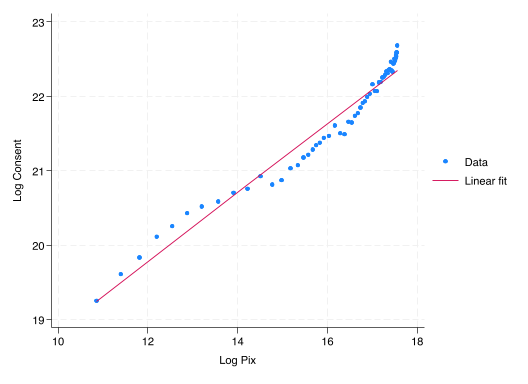

In [61]:
twoway ///
(scatter l_pix l_consent) (lfit l_pix l_consent), ///
xtitle("Log Pix") ytitle("Log Consent") ///
legend(label(1 "Data") label(2 "Linear fit"))

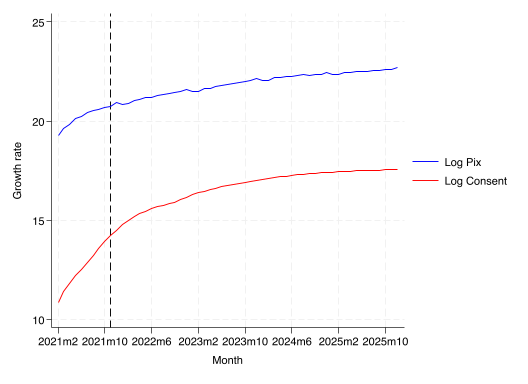

In [62]:
twoway ///
 (line l_pix mdate, sort lcolor(blue)) ///
 (line l_consent mdate, sort lcolor(red)), ///
 xline(`=tm(2021m11)', lpattern(dash)) ///
 legend(order(1 "Log Pix" 2 "Log Consent")) ///
 xtitle("Month") ytitle("Growth rate") ///
 xlabel(`=tm(2021m2)'(8)`=tm(2025m12)', format(%tm))

### Baseline Regression Analysis

In [63]:
newey l_pix l_consent, lag(3)
newey l_pix l_consent ibc_br selic fx_m parts, lag(3)


Regression with Newey–West standard errors      Number of obs     =         59
Maximum lag = 3                                 F(  1,        57) =     434.11
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
   l_consent |   .4638452   .0222626    20.84   0.000     .4192652    .5084253
       _cons |   14.20667   .3629138    39.15   0.000     13.47995     14.9334
------------------------------------------------------------------------------

Regression with Newey–West standard errors      Number of obs     =         58
Maximum lag = 3                                 F(  5,        52) =     262.72
                                                Prob > F          =     0.0000

----------

### Transformations

In [64]:
dfuller l_pix, lags(5) trend
gen gr_pix = d.l_pix
dfuller gr_pix, lags(4) trend


Augmented Dickey–Fuller test for unit root

Variable: l_pix                            Number of obs  = 53
                                           Number of lags =  5

H0: Random walk with or without drift

                                       Dickey–Fuller
                   Test      -------- critical value ---------
              statistic           1%           5%          10%
--------------------------------------------------------------
 Z(t)            -1.549       -4.143       -3.497       -3.178
--------------------------------------------------------------
MacKinnon approximate p-value for Z(t) = 0.8116.
(1 missing value generated)

Augmented Dickey–Fuller test for unit root

Variable: gr_pix                           Number of obs  = 53
                                           Number of lags =  4

H0: Random walk with or without drift

                                       Dickey–Fuller
                   Test      -------- critical value ---------
              sta

In [65]:
dfuller l_consent, lags(7) trend
gen gr_consent = d.l_consent
dfuller gr_consent, lags(6) trend


Augmented Dickey–Fuller test for unit root

Variable: l_consent                        Number of obs  = 51
                                           Number of lags =  7

H0: Random walk with or without drift

                                       Dickey–Fuller
                   Test      -------- critical value ---------
              statistic           1%           5%          10%
--------------------------------------------------------------
 Z(t)            -3.983       -4.148       -3.499       -3.179
--------------------------------------------------------------
MacKinnon approximate p-value for Z(t) = 0.0093.
(1 missing value generated)

Augmented Dickey–Fuller test for unit root

Variable: gr_consent                       Number of obs  = 51
                                           Number of lags =  6

H0: Random walk with or without drift

                                       Dickey–Fuller
                   Test      -------- critical value ---------
              sta

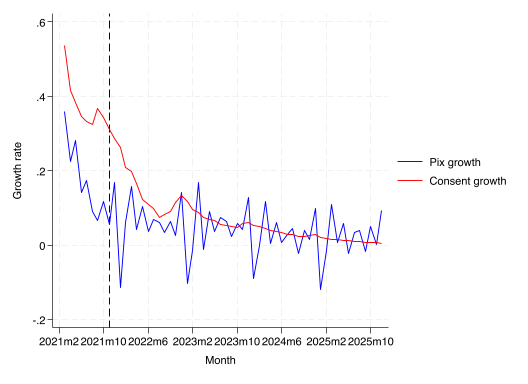

In [66]:
twoway ///
 (line gr_pix mdate, sort lcolor(blue)) ///
 (line gr_consent mdate, sort lcolor(red)), ///
 xline(`=tm(2021m11)', lpattern(dash)) ///
 legend(order(1 "Pix growth" 2 "Consent growth")) ///
 xtitle("Month") ///
 ytitle("Growth rate") ///
 xlabel(`=tm(2021m2)'(8)`=tm(2025m12)', format(%tm))

In [67]:
newey gr_pix gr_consent, lag(3)
newey gr_pix gr_consent ibc_br selic fx_m parts, lag(3)


Regression with Newey–West standard errors      Number of obs     =         58
Maximum lag = 3                                 F(  1,        56) =      12.86
                                                Prob > F          =     0.0007

------------------------------------------------------------------------------
             |             Newey–West
      gr_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
  gr_consent |   .4027692   .1123272     3.59   0.001     .1777508    .6277877
       _cons |    .012688   .0088831     1.43   0.159    -.0051071     .030483
------------------------------------------------------------------------------

Regression with Newey–West standard errors      Number of obs     =         57
Maximum lag = 3                                 F(  5,        51) =       9.91
                                                Prob > F          =     0.0000

----------

### Interrupted Time Series

In [68]:
gen post = (mdate >= tm(2021m11))
gen t = _n
gen t_post = (mdate - tm(2021m11) + 1) * post

In [69]:
newey l_pix t post t_post, lag(3)


Regression with Newey–West standard errors      Number of obs     =         59
Maximum lag = 3                                 F(  3,        55) =     431.29
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           t |   .1736969   .0176208     9.86   0.000     .1383841    .2090097
        post |   .1161886   .0911494     1.27   0.208    -.0664787     .298856
      t_post |  -.1364636   .0182215    -7.49   0.000    -.1729802    -.099947
       _cons |   19.27589    .103159   186.86   0.000     19.06915    19.48262
------------------------------------------------------------------------------


In [70]:
newey l_pix t post t_post ibc_br selic fx_m parts, lag(3)


Regression with Newey–West standard errors      Number of obs     =         58
Maximum lag = 3                                 F(  7,        50) =     779.40
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           t |   .1586024   .0198706     7.98   0.000      .118691    .1985137
        post |   -.057989   .0899102    -0.64   0.522     -.238579     .122601
      t_post |  -.1344445   .0195921    -6.86   0.000    -.1737963   -.0950927
      ibc_br |   .0059802   .0024662     2.42   0.019     .0010267    .0109337
       selic |  -.0135893    .007673    -1.77   0.083     -.029001    .0018223
        fx_m |   -.043691   .0502437    -0.87   0.389    -.1446085    .0572265
       parts

- **Interpretation:** <br>

    - The results from the interrupted time series (ITS) regression with Newey–West standard errors (lag = 3) indicate a clear structural change in the growth dynamics of Pix following the formal implementation of Open Finance in November 2021. Prior to the intervention, Pix exhibited a strong and statistically significant upward trend. The coefficient on the time variable (0.159, p < 0.001) implies that on average, during the pre-policy period, Pix has a monthly growth rate of roughly 17%. <br>

    - The coefficient on the post-policy dummy is negative but statistically insignificant (-0.0580, p = 0.522), suggesting that the introduction of Open Finance did not generate an immediate level shift in Pix transactions. In other words, there is no evidence of a discrete jump in Pix activity at the moment of policy implementation. <br>

    - However, the interaction term capturing the post-intervention trend change (t_post) is negative and highly significant (-0.134, p < 0.001). This implies a substantial reduction in the slope of the time trend after November 2021. Combining the pre-policy trend (0.159) with the post-policy adjustment (-0.134) yields a post-policy trend of approximately 2.4% monthly growth rate. Thus, while Pix continued to expand after the introduction of Open Finance, its rate of growth slowed markedly relative to the initial expansion phase. Several factors may explain this deceleration: <br>

        - First, the early period of Pix was characterized by rapid diffusion and strong network externalities, typical of digital platform adoption. Once a critical mass of users and merchants had joined the system, marginal growth naturally declined as market penetration increased and the pool of new adopters shrank. <br>

        -  Second, part of the initial expansion reflected a substitution effect, as consumers shifted from cash, bank transfers, and cards to Pix; once this substitution process matured, incremental gains became smaller. <br>
        
        - Finally, Open Finance may have contributed to a structural normalization of the payment ecosystem, shifting the system from an explosive adoption phase to a more stable, efficiency-driven expansion path.